In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
os.makedirs('/root/.kaggle', exist_ok=True)

from google.colab import files
files.upload()  # kaggle.jsonを選択
os.rename('/content/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

os.system('kaggle datasets download -d yasserh/wine-quality-dataset')
os.system('unzip -o wine-quality-dataset.zip')

df = pd.read_csv('WineQT.csv')
print(df.shape)
print(df.head())

Saving kaggle.json to kaggle.json
(1143, 13)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4     

In [2]:
# 欠損値確認
print("欠損値:")
print(df.isnull().sum())
print()

# qualityの分布
print("qualityの分布:")
print(df['quality'].value_counts().sort_index())
print()

print(df.describe())

欠損値:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

qualityの分布:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.

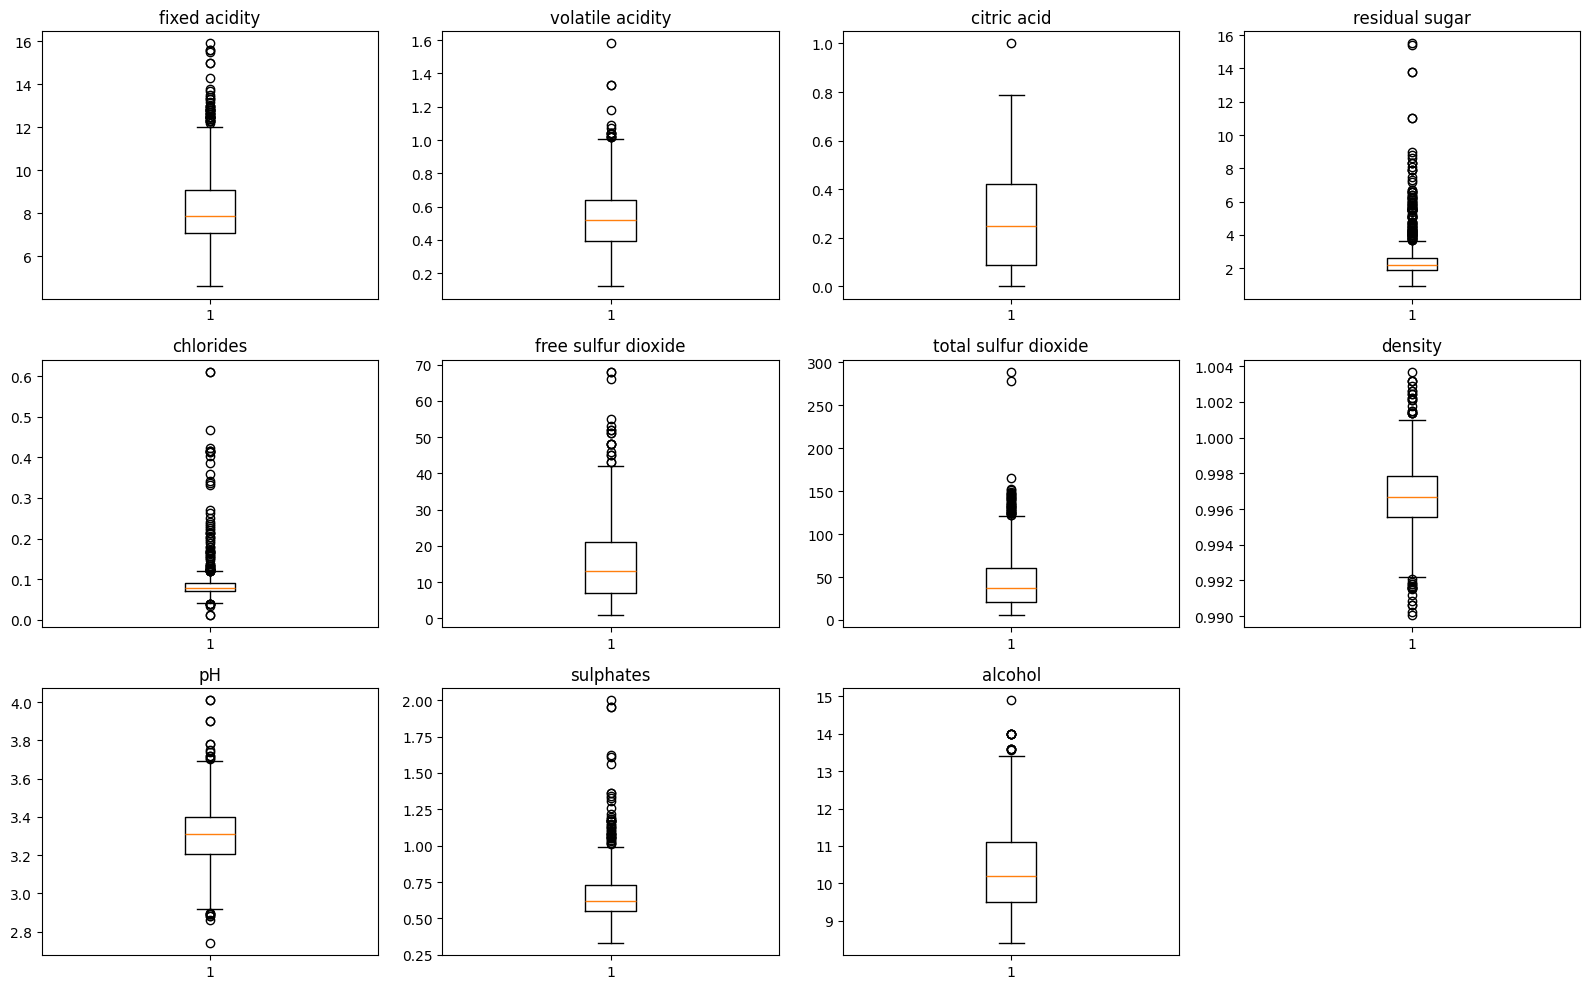

In [3]:
cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
        'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
        'density', 'pH', 'sulphates', 'alcohol']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

In [4]:
from scipy.stats.mstats import winsorize

cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
        'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
        'density', 'pH', 'sulphates', 'alcohol']

df_clean = df.drop(columns=['Id']).copy()

for col in cols:
    df_clean[col] = winsorize(df_clean[col], limits=[0.01, 0.01])

print(df_clean[cols].describe().round(3))

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count       1143.000          1143.000     1143.000        1143.000   
mean           8.299             0.530        0.268           2.506   
std            1.700             0.174        0.196           1.163   
min            5.100             0.190        0.000           1.400   
25%            7.100             0.392        0.090           1.900   
50%            7.900             0.520        0.250           2.200   
75%            9.100             0.640        0.420           2.600   
max           13.300             1.020        0.730           8.300   

       chlorides  free sulfur dioxide  total sulfur dioxide   density  \
count   1143.000             1143.000              1143.000  1143.000   
mean       0.086               15.547                45.619     0.997   
std        0.040                9.953                31.319     0.002   
min        0.041                3.000                 8.000     0.99

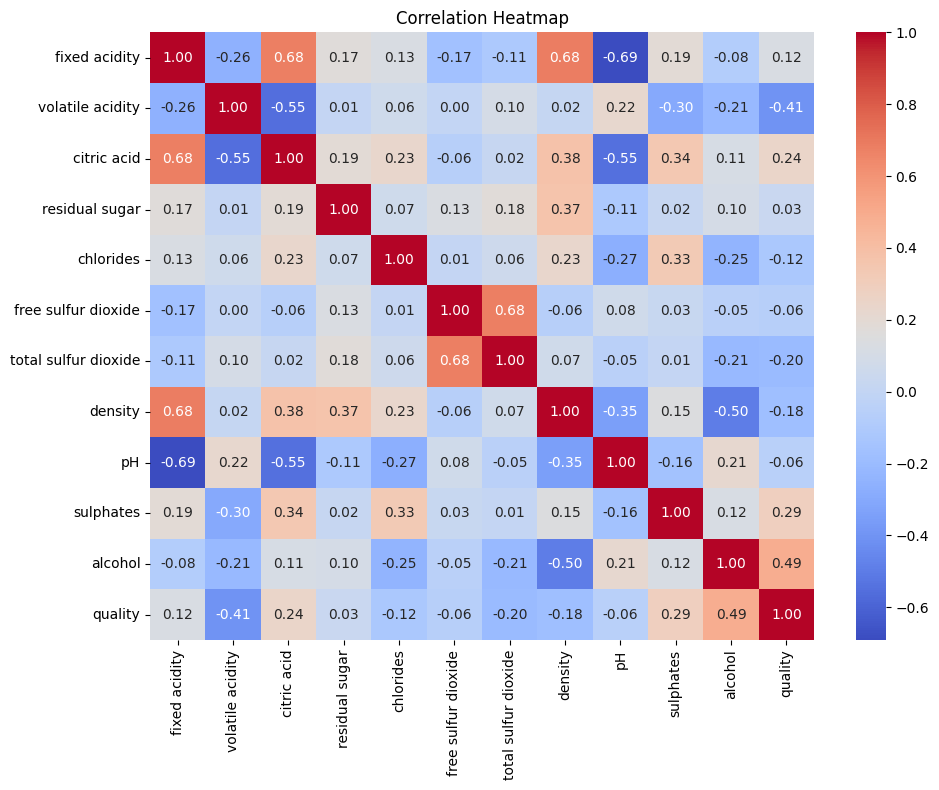

qualityとの相関:
quality                 1.000
alcohol                 0.488
sulphates               0.292
citric acid             0.244
fixed acidity           0.123
residual sugar          0.033
pH                     -0.056
free sulfur dioxide    -0.062
chlorides              -0.122
density                -0.176
total sulfur dioxide   -0.205
volatile acidity       -0.405
Name: quality, dtype: float64


In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print("qualityとの相関:")
print(df_clean.corr()['quality'].sort_values(ascending=False).round(3))

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_clean.drop(columns=['quality'])
y = df_clean['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"訓練データ: {X_train.shape}")
print(f"テストデータ: {X_test.shape}")
print()
print("訓練データのquality分布:")
print(y_train.value_counts().sort_index())

訓練データ: (914, 11)
テストデータ: (229, 11)

訓練データのquality分布:
quality
3      5
4     26
5    386
6    370
7    114
8     13
Name: count, dtype: int64


SVM accuracy: 0.6769

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.73      0.80      0.76        97
           6       0.61      0.73      0.67        92
           7       0.77      0.34      0.48        29
           8       0.00      0.00      0.00         3

    accuracy                           0.68       229
   macro avg       0.35      0.31      0.32       229
weighted avg       0.65      0.68      0.65       229



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


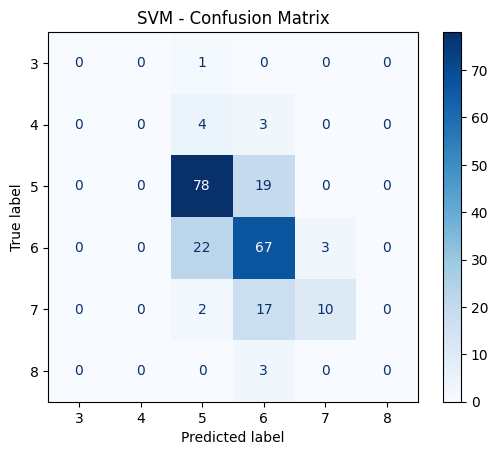

In [7]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

print(f"SVM accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print()
print(classification_report(y_test, y_pred_svm))

cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
disp.plot(cmap='Blues')
plt.title('SVM - Confusion Matrix')
plt.show()

In [8]:
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

# XGBoostはラベルを0始まりの連番にする必要がある
y_train_xgb = y_train - y_train.min()
y_test_xgb = y_test - y_train.min()

models = {
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss')
}

for name, model in models.items():
    if name == 'XGBoost':
        model.fit(X_train, y_train_xgb)
        y_pred = model.predict(X_test) + y_train.min()
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"{name} accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    print()

Gradient Boosting accuracy: 0.6638
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.71      0.78      0.75        97
           6       0.65      0.66      0.66        92
           7       0.62      0.52      0.57        29
           8       0.00      0.00      0.00         3

    accuracy                           0.66       229
   macro avg       0.33      0.33      0.33       229
weighted avg       0.64      0.66      0.65       229


XGBoost accuracy: 0.6812
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.71      0.79      0.75        97
           6       0.67      0.67      0.67        92
           7       0.73      0.55      0.63        29
           8       0.33      0.33      0.33         3

    accuracy    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_model = XGBClassifier(random_state=42, eval_metric='mlogloss')
y_xgb = y - y.min()

scores = cross_val_score(xgb_model, X, y_xgb, cv=skf, scoring='accuracy')

print(f"各foldのaccuracy: {scores.round(4)}")
print(f"平均accuracy: {scores.mean():.4f}")
print(f"標準偏差: {scores.std():.4f}")

各foldのaccuracy: [0.5983 0.6026 0.655  0.6272 0.6886]
平均accuracy: 0.6343
標準偏差: 0.0339


In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

xgb_grid = XGBClassifier(random_state=42, eval_metric='mlogloss')

grid_search = GridSearchCV(
    xgb_grid, param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X, y_xgb)

print(f"最適パラメータ: {grid_search.best_params_}")
print(f"最高accuracy: {grid_search.best_score_:.4f}")

最適パラメータ: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
最高accuracy: 0.5932


In [11]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [50, 100, 150, 200, 300],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_random = XGBClassifier(random_state=42, eval_metric='mlogloss')

random_search = RandomizedSearchCV(
    xgb_random, param_dist, n_iter=30, cv=5,
    scoring='accuracy', random_state=42, n_jobs=-1
)
random_search.fit(X, y_xgb)

print(f"最適パラメータ: {random_search.best_params_}")
print(f"最高accuracy: {random_search.best_score_:.4f}")

最適パラメータ: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
最高accuracy: 0.5941


In [14]:
!pip install optuna
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0)
    }

    model = XGBClassifier(**params, random_state=42, eval_metric='mlogloss')
    scores = cross_val_score(model, X, y_xgb, cv=5, scoring='accuracy')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print(f"最適パラメータ: {study.best_params}")
print(f"最高accuracy: {study.best_value:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.1 MB/s eta 0:00:00


[I 2026-06-17 12:39:11,851] A new study created in memory with name: no-name-50a438b4-9354-40cc-ae61-5873cf8c378f
[I 2026-06-17 12:39:13,604] Trial 0 finished with value: 0.5669654485558875 and parameters: {'n_estimators': 110, 'max_depth': 6, 'learning_rate': 0.10863399866797757, 'subsample': 0.9402371588938379, 'colsample_bytree': 0.7457465751564796}. Best is trial 0 with value: 0.5669654485558875.
[I 2026-06-17 12:39:17,370] Trial 1 finished with value: 0.5529571745958785 and parameters: {'n_estimators': 277, 'max_depth': 8, 'learning_rate': 0.1462136409164166, 'subsample': 0.850528444569938, 'colsample_bytree': 0.9021190453859114}. Best is trial 0 with value: 0.5669654485558875.
[I 2026-06-17 12:39:18,162] Trial 2 finished with value: 0.5826859725733547 and parameters: {'n_estimators': 86, 'max_depth': 3, 'learning_rate': 0.012185720911611506, 'subsample': 0.9184837008320259, 'colsample_bytree': 0.7117017806658751}. Best is trial 2 with value: 0.5826859725733547.
[I 2026-06-17 12:3

最適パラメータ: {'n_estimators': 122, 'max_depth': 4, 'learning_rate': 0.06486474110481545, 'subsample': 0.8882685891827944, 'colsample_bytree': 0.7805060488913728}
最高accuracy: 0.5993
